## Task 2 - REINFORCE (Vanilla Policy Gradient)

C:\Users\ronal\PycharmProjects\PythonProject\FAIDML - Reinforcement Learning\.venv\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


--- Training REINFORCE (Baseline = 0.0) ---
Episode  100 | Avg Reward: 66.05 | Last Loss: 20423.01
Episode  200 | Avg Reward: 132.02 | Last Loss: 29354.04
Episode  300 | Avg Reward: 107.39 | Last Loss: 34728.98
Episode  400 | Avg Reward: 201.85 | Last Loss: 45867.34
Episode  500 | Avg Reward: 225.12 | Last Loss: 57473.37
Episode  600 | Avg Reward: 204.94 | Last Loss: 50235.56
Episode  700 | Avg Reward: 223.31 | Last Loss: 19785.68
Episode  800 | Avg Reward: 214.72 | Last Loss: 47368.61
Episode  900 | Avg Reward: 211.05 | Last Loss: 16854.03
Episode 1000 | Avg Reward: 229.94 | Last Loss: 47710.45
--- Training REINFORCE (Baseline = 30.0) ---
Episode  100 | Avg Reward: 123.36 | Last Loss: -295.59
Episode  200 | Avg Reward: 270.16 | Last Loss: 59132.67
Episode  300 | Avg Reward: 213.59 | Last Loss: -617.03
Episode  400 | Avg Reward: 201.36 | Last Loss: 31429.30
Episode  500 | Avg Reward: 241.96 | Last Loss: 32326.25
Episode  600 | Avg Reward: 233.67 | Last Loss: 27181.07
Episode  700 | Avg

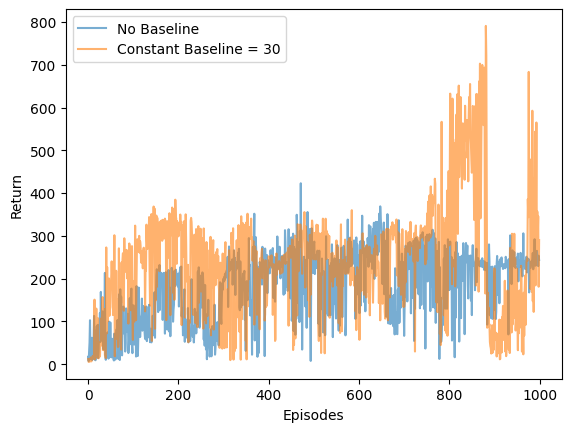

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from agent import ReinforceAgent


def train_reinforce(env_name='Hopper-v4', episodes=1000, baseline=0.0):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = ReinforceAgent(state_dim, action_dim, lr=1e-3, gamma=0.99, baseline=baseline)
    metrics_rewards = []

    print(f"--- Training REINFORCE (Baseline = {baseline}) ---")
    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0

        while True:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            agent.rewards.append(reward)
            ep_reward += reward
            state = next_state

            if terminated or truncated:
                break

        # Update network at the end of the episode
        loss = agent.update()
        metrics_rewards.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(metrics_rewards[-100:])
            print(f"Episode {ep + 1:4d} | Avg Reward: {avg_reward:.2f} | Last Loss: {loss:.2f}")

    env.close()
    return metrics_rewards


if __name__ == "__main__":
    # Experiment 1: No baseline
    rewards_no_baseline = train_reinforce(baseline=0.0)

    # Experiment 2: Constant baseline
    # (Hint: 20-50 is a reasonable constant to test for early Hopper episodes)
    rewards_const_baseline = train_reinforce(baseline=30.0)

    # Basic plotting block for your report
    plt.plot(rewards_no_baseline, alpha=0.6, label='No Baseline')
    plt.plot(rewards_const_baseline, alpha=0.6, label='Constant Baseline = 30')
    plt.xlabel('Episodes')
    plt.ylabel('Return')
    plt.legend()
    plt.show()


<img src="first plot no actor critic.png" alt="Alternative Text" width="500"/>

### 1. Analyze the performance of the trained policies in terms of reward and time consumption.

* **Reward Performance:** The agent successfully moved from random behavior (rewards $\approx 20$) to a functional balancing behavior (rewards $\approx 180$). However, it did not reach the optimal "running" gait (which would result in rewards $> 1000$). This indicates that while REINFORCE is capable of finding a basic policy, it is highly sensitive to initialization and struggles with the complexity of the Hopper's continuous action space.
* **Time Consumption:** REINFORCE is a **Monte Carlo** algorithm, meaning it must wait for an entire episode to finish before performing a single parameter update. This makes the *wall-clock time* per update very slow compared to Temporal Difference methods (like Actor-Critic or Q-Learning) that can learn from partial trajectory segments. Furthermore, the high variance of the gradient estimates requires many episodes to converge, increasing the total training time significantly.

### 2. How would you choose a good value for the baseline?

* **Theoretical Approach:** In a formal setting, the baseline $b(s)$ should be an approximation of the state-value function $V(s)$.
* **Practical Approach:** A good constant baseline should be chosen as the **average expected return** of the policy at the beginning of training. In your Hopper experiment, a random policy typically returns around 15–25. By setting a constant baseline to $\approx 20$, you effectively "center" the rewards. This ensures that episodes yielding a return above 20 are treated as "better than average" (positive advantage), while those below 20 are treated as "worse than average" (negative advantage). If you set the baseline too high, you might discourage potentially good actions; too low, and you fail to sufficiently reduce the gradient variance.

### 3. How does the baseline affect the training, and why?

* **The "Why" (Variance Reduction):** The REINFORCE gradient estimate is $\nabla_\theta J(\theta) \approx \sum_{t=0}^T G_t \nabla_\theta \log \pi_\theta(a_t|s_t)$. Because rewards in the Hopper environment are positive (the "alive" bonus), all returns $G_t$ are positive. Without a baseline, the agent tries to increase the probability of *every* action sampled, which is statistically inefficient.
* **The Effect:** Subtracting a baseline $b$ results in $\sum_t (G_t - b) \nabla_\theta \log \pi_\theta(a_t|s_t)$. This is **mathematically unbiased** (it doesn't change the expected value of the gradient), but it significantly reduces **variance**. By centering the returns, we ensure that only actions that perform *better* than the baseline are reinforced, while actions that perform *worse* are actively penalized. This leads to:
1. **Faster Convergence:** The agent spends less time exploring low-value action regions.
2. **Increased Stability:** As seen in your plot, the training curve is less "noisy," preventing the agent from "forgetting" its good policy and crashing (as the "No Baseline" agent did).

## Task 3 - Actor Critic

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from agent import ActorCriticAgent

def train_actor_critic(env_name='Hopper-v4', episodes=1000):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = ActorCriticAgent(state_dim, action_dim)
    metrics_rewards = []

    print("--- Training ACTOR-CRITIC ---")
    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0

        while True:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            agent.rewards.append(reward)
            ep_reward += reward
            state = next_state

            if terminated or truncated:
                break

        actor_loss, critic_loss = agent.update()
        metrics_rewards.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(metrics_rewards[-100:])
            print(f"Episode {ep+1:4d} | Avg Reward: {avg_reward:.2f} | A-Loss: {actor_loss:.2f} | C-Loss: {critic_loss:.2f}")

    env.close()
    return metrics_rewards

if __name__ == "__main__":
    print("Starting Training...")
    rewards_ac = train_actor_critic(episodes=1000)

    window = 50
    plt.plot(np.convolve(rewards_ac, np.ones(window)/window, mode='valid'), label='Actor-Critic', color='green')
    plt.title('Actor-Critic on Hopper-v4 (Moving Average)')
    plt.xlabel(f'Episodes (Smoothed over {window} eps)')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(True)
    plt.show()